# Supplementary Fig. 10 — distribution of sample DCS 'VAFs' (error-rates) at example positions

- **a** — distribution of **mean position error rates** across the SNV/indel panel (174,366 positions;
  positions with depth < 500 excluded, and positions with 0 variant reads across all samples not shown).
  Eight example positions across the distribution are numbered (1–8) for panel b.
- **b** — for each of those 8 positions (chosen to have ≥ 1 variant read in ≥ 16 samples with depth ≥ 500
  and VAF < 1 %), the **cumulative distribution of per-sample DCS 'VAFs'** (error rates, blue) with the
  binomial distribution expected under the mean position error rate (orange line).

Pilot set = 20 pre-AML + 20 control UKCTOCS samples on sequencing lane **SLX_20124**.

> **Note on the example positions.** The code selects **10** example positions (evenly spaced by rank
> across the error-rate distribution). The published figure shows **8** of these — the same 8 positions
> (chr20:57429995, chr21:36164864, chr11:32450101, chr3:128202812, chr20:57429188, chrX:123197826,
> chr20:57429508, chr20:57428925) — with two of the ten dropped and the 2×5 grid trimmed to 2×4 during
> figure assembly.

## Data availability

Reads the **DCS error-model output table** for the pilot (per-position, per-sample variant/depth values).
This is a large intermediate file with per-sample data and is **not uploaded** (code-only):

In [ ]:
# imported packages
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
from scipy.stats import binom
import pandas as pd

In [1]:
#define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'

In [5]:
library = 'SLX_20124'

In [ ]:
DCS = pd.read_csv('Data_files/'+library+'_dataframe_all_positions_results_cases_and_controls_DCS.csv')
DCS = DCS.drop(columns=['Unnamed: 0'])
DCS

In [ ]:
samples_to_exclude = ['C92_043_s6', 'CNTRL_197_s6'] #On this sequencing lane (SLX_20124), C92_043_s6 looks comtaminated on CNV panel and CNTRL_197_s6 had mean depth <500 (both later resequenced)

In [ ]:
def plot_binomial_cumulatives_across_depths(depths, error_rate, ax):
    
    maximum_variant_depth = []
    for depth in depths:
        x = np.arange(binom.ppf(0.0001, depth, error_rate), binom.ppf(0.99999, depth, error_rate))
        maximum_variant_depth.append(max(x))

    max_error_rate = max(maximum_variant_depth)/min(depths)
    
    y_values = []
    zero_values = []

    for depth in depths:
        x = np.arange(0, binom.ppf(0.99999, depth, error_rate))
        x = [x1 for x1 in x if x1 !=0]
        
        binomial_sf = list(binom.sf([x1-1 for x1 in x], depth, error_rate))
        total_zeros = binom.pmf(0, depth, error_rate)
        zero_values.append(total_zeros)

        error_rates = [x1/depth for x1 in x]

        #interpolation
        f = interp1d(error_rates, binomial_sf, bounds_error=False, fill_value=(binomial_sf[0], 0)) #if no data below minimum x, fill with 1-total zeros, if no data above max x then fill with 0
        xnew = np.linspace(0, max_error_rate, num=50000)
        ynew = [y for y in f(xnew)]

        y_values.append(ynew)
        
    summed_y = [sum(y2) for y2 in zip(*y_values)]
    ax.plot(xnew, [y/len(depths) for y in summed_y], color = orange3, lw = 3)
    
    proportion_zero = np.sum(zero_values)/len(depths)
    ax.plot([0, 0], [1, 1-proportion_zero], color = orange3, lw =3)
    
    ax.set_ylim(0, 1.02)

    return ax

In [ ]:
def plotting_positions_and_binomial_10_cumulative(df, minimum_depth, VAF_CUT, samples_to_exclude, SSCS_or_DCS):

    data_values = df.values.tolist()

    all_position_error_rates = {}
    all_position_depths = {}
    mean_position_error_rates = {}
    all_mean_error_rates = []
    
    for position in data_values:
        position_error_rates = []
        position_error_rates_non_zero = []
        position_depths = []
        chromosome = position[0]
        pos = position[1]
        ref = position[2]
        alt = position[3]

        for sample in position[6:]:
            if sample not in [0, '0']:
                var_depth = int(sample.split(',')[0])
                tot_depth = int(sample.split(',')[1])
                sample_name = sample.split(',')[2]

                if sample_name not in samples_to_exclude:
                
                    if tot_depth > minimum_depth:
                        if var_depth < VAF_CUT*tot_depth:
                            if var_depth !=0:
                                error_rate = var_depth/tot_depth
                                position_error_rates_non_zero.append(error_rate)
                            else:
                                error_rate = 0

                            position_error_rates.append(error_rate)
                            position_depths.append(tot_depth)


        if len(position_error_rates_non_zero)>0:
            all_position_error_rates[(chromosome, pos, ref, alt)]=position_error_rates
            mean_position_error_rate = np.mean(position_error_rates)
            all_mean_error_rates.append(mean_position_error_rate)
            all_position_depths[(chromosome, pos, ref, alt)]=position_depths
            
        if len(position_error_rates_non_zero)>16: #only look at positions where 16 samples had coverage at that position
            mean_position_error_rate = np.mean(position_error_rates)
            mean_position_error_rates[(chromosome, pos, ref, alt)]=mean_position_error_rate

    #create a dictionary of the position error rates, sorted from highest error rate to lowest error rate
    sorted_position_error_rates = {k: v for k, v in sorted(mean_position_error_rates.items(), key=lambda item: item[1], reverse = False)}
    list_error_rates = list(sorted_position_error_rates.keys())

    number_of_pos_to_choose = 10
    
    error_rates_plotted = []
    
    #OR choose error rates to plot at even intervals of ranked list of error rates
    chosen_positions_to_plot = {}
    error_positions = np.linspace(0, len(list_error_rates)-1, number_of_pos_to_choose)

    for i in error_positions:
        position = list_error_rates[int(i)]
        position_depth = all_position_depths[position]
        chosen_positions_to_plot[position]=(all_position_error_rates[position], position_depth)
        error_rates_plotted.append(mean_position_error_rates[position])
        
    #PLOT THE RESULTS....
    fig, axes = plt.subplots(2, 5, figsize = (30, 8))
    matplotlib.pyplot.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.75, hspace=1.2)

    ax1 = axes[0, 0]
    ax2 = axes[0, 1]
    ax3 = axes[0, 2]
    ax4 = axes[0, 3]
    ax5 = axes[0, 4]
    ax6 = axes[1, 0]
    ax7 = axes[1, 1]
    ax8 = axes[1, 2]
    ax9 = axes[1, 3]
    ax10 = axes[1, 4]

    axis_numbers = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]

    n = 0
    for k, v in chosen_positions_to_plot.items(): #plot a histogram of the sample error rates at specific positions
        chromosome = k[0]
        pos = k[1]
        ref = k[2]
        alt = k[3]
        position_depths = v[1]
        mean_position_depth = np.mean(v[1])
        mean_error_rate = sorted_position_error_rates[k]
#         print(v[0])
        
        #BINOMIAL PLOTS
        depth = int(mean_position_depth)

        plot_binomial_cumulatives_across_depths(position_depths, mean_error_rate, axis_numbers[n])

        #PLOT THE LINEAR HISTOGRAM
        axis_numbers[n].set_title(chromosome+', '+str(pos)+', '+ref+'>'+alt+'\nmean error rate = '+str(round(mean_error_rate, 5)), fontsize = 16, y = 1.1)

        sorted_data = sorted(v[0], reverse = False)
        cumulative_number = []
        cumulat = 1
        for i in sorted_data:
            cumulative_number.append(cumulat)
            cumulat-=(1/len(sorted_data))
#         normed_value = len(sorted_data)
#         cumulative_number = (np.arange(np.size(sorted_data))/normed_value)

        axis_numbers[n].scatter(sorted_data, cumulative_number, color = blue3, alpha = 0.5, lw = 1, edgecolor = 'k',marker = 'o', s = 150, zorder = 100)

        #LABEL THE PLOTS WITH A NUMBER IN A CIRCLE
        axis_numbers[n].text(-0.125, 1.22, n+1, horizontalalignment='center', fontsize = 16, 
                                 bbox=dict(facecolor='none', edgecolor=grey4, boxstyle='circle, pad=0.4'),
                                transform=axis_numbers[n].transAxes)
        
        axis_numbers[n].set_xlim(0, max(sorted_data)*1.1)
        
        n+=1

    # axis labels
    for ax in axes.flatten():
        ax.set_xlabel('sample VAFs', fontsize = 16, labelpad = 6, fontweight = 'medium')
        ax.set_ylabel('cumulative', fontsize = 16, labelpad = 6, fontweight = 'medium')

        ax.xaxis.set_tick_params(width=1, color = grey3, length = 6)
        ax.yaxis.set_tick_params(width=1, color = grey3, length = 6)

        for item in (ax.get_xticklabels() + ax.get_yticklabels()):
            item.set_fontsize(16)

        #Only show the required axis lines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(1)
            ax.spines[axis].set_color(grey3)

        ax.xaxis.set_tick_params(width=1, color = grey3, length = 6, rotation = 45)


    legend_elements = [Line2D([0], [0], marker = 'o', color = blue3, alpha = 0.7, markersize = 10, lw=0, label='Distribution of actual sample error rates at position'),\
                        Line2D([0], [0], marker = '_', color = orange3, alpha = 1, lw=3, label='Binomial distribution (using position error rate and actual depths)')]    
    ax3.legend(ncol=2, handles=legend_elements, loc='center', bbox_to_anchor=(0.5, 1.6), fancybox = True, fontsize = 18)

    ax5.text(0.99, 1.55, SSCS_or_DCS, horizontalalignment='right', fontsize = 16, transform=ax5.transAxes,
    bbox=dict(facecolor='none', edgecolor=grey4, boxstyle='round, pad=0.5'))
    
    VAF_save = VAF_CUT*100
    if VAF_save>=1:
        VAF_save = int(VAF_save)
    else:
        VAF_save = VAF_save.replace('.', '_')
    
    
    plt.show()
    
    return all_mean_error_rates, error_rates_plotted

In [ ]:
def plot_which_error_rates_were_plotted(all_mean_error_rates, error_rates_chosen, SSCS_or_DCS, y_lim, VAF_CUT, bounds):
    #plot distribution of mean error rates
    fig, ax1 = plt.subplots(1, 1, figsize = (16, 6))

    ax1.hist(all_mean_error_rates, bins = 75, color = blue2)
    
    n = 1
    for i in error_rates_chosen:
        print(i)
        ax1.plot([i, i], [0, y_lim], color = grey3, lw = 2.5, linestyle = ':', zorder = 50)
        ax1.text(i, y_lim*1.35, n, horizontalalignment='center', fontsize = 16, bbox=dict(facecolor='none', edgecolor=grey4, boxstyle='circle, pad=0.4'))
        n+=1
        
    # axis labels
    ax1.set_xlabel('mean position error rate ('+SSCS_or_DCS+')', fontsize = 16, labelpad = 6, fontweight = 'medium')
    ax1.set_ylabel('count', fontsize = 16, labelpad = 6, fontweight = 'medium')

    ax1.xaxis.set_tick_params(width=1, which = 'both', color = grey3, length = 8)
    ax1.yaxis.set_tick_params(width=1, color = grey3, length = 6)
    
    for item in (ax1.get_xticklabels() + ax1.get_yticklabels()):
        item.set_fontsize(16)

    #Only show the required axis lines
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    for axis in ['bottom','left']:
        ax1.spines[axis].set_linewidth(1)
        ax1.spines[axis].set_color(grey3)

    ax1.set_yscale('log')
        
    VAF_save = VAF_CUT*100
    if VAF_save>=1:
        VAF_save = int(VAF_save)
    else:
        VAF_save = VAF_save.replace('.', '_')


    return plt.show()

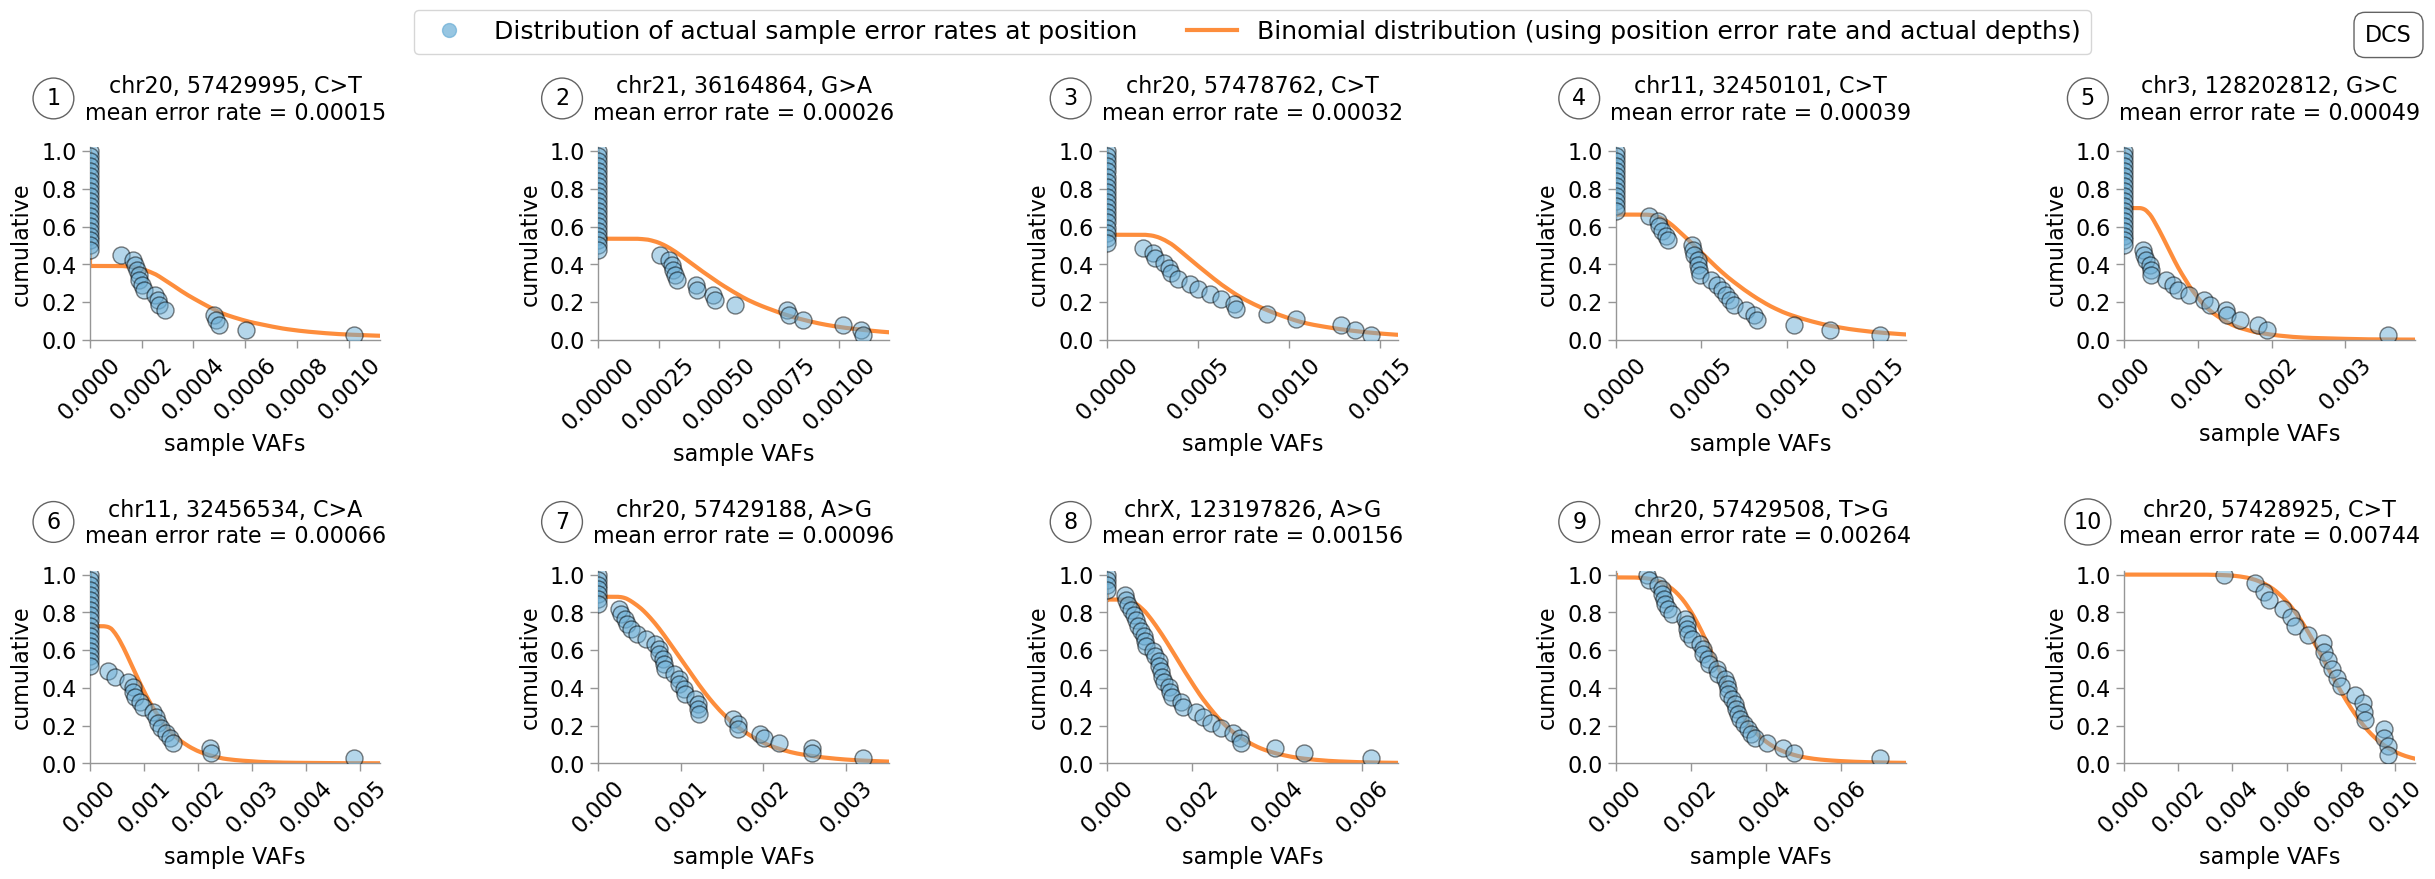

In [ ]:
DCS_position_error_rates, DCS_chosen_positions = plotting_positions_and_binomial_10_cumulative(DCS, 500, 0.01, samples_to_exclude, 'DCS')

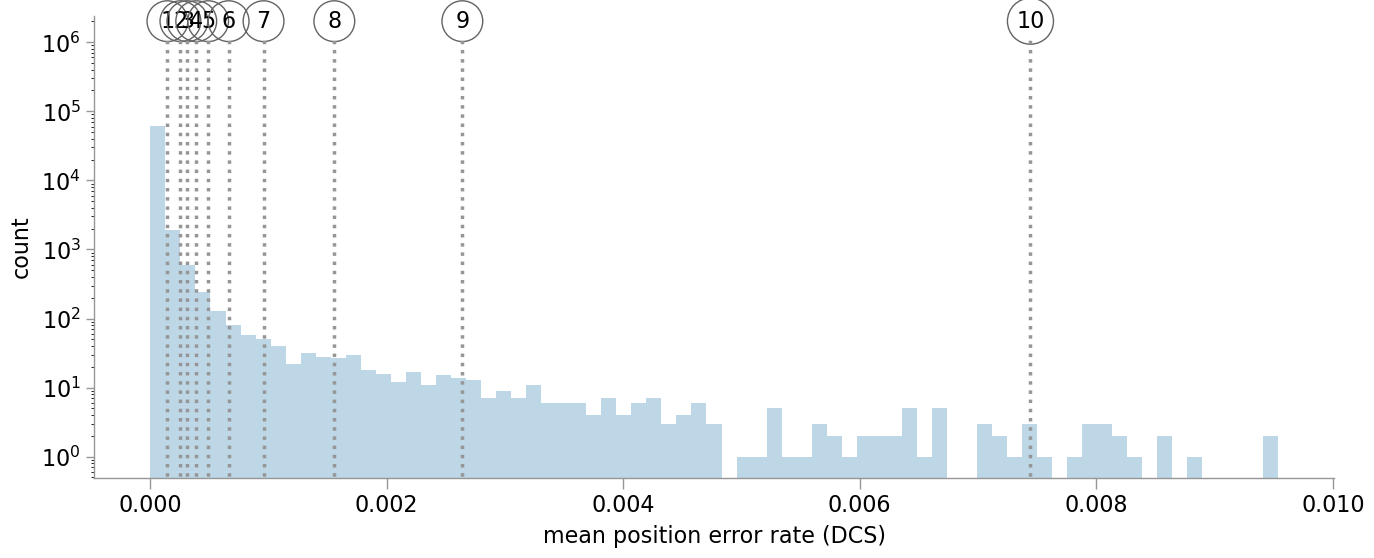

In [ ]:
plot_which_error_rates_were_plotted(DCS_position_error_rates, DCS_chosen_positions, 'DCS', 1200000, 0.01, 'unbounded_error_rates')